In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("8-fraud_detection.csv")

In [4]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [5]:
df["is_fraud"].unique()

array([0, 1])

In [6]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [7]:
#imbalanced dataset

In [8]:
df.isnull().sum()

transaction_amount        0
transaction_risk_score    0
is_fraud                  0
dtype: int64

In [10]:
X =df.drop("is_fraud",axis=1)
y = df["is_fraud"]

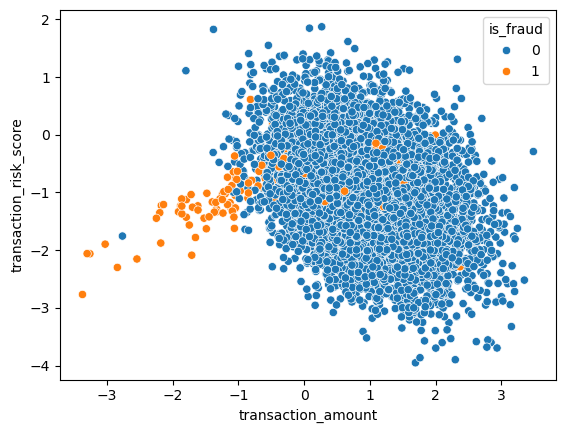

In [15]:
sns.scatterplot(x =X["transaction_amount"], y=X["transaction_risk_score"],hue = y)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=15)

In [17]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()


In [19]:
penalty = ["l1","l2","elasticnet"]
c_values =[100,10,1,0.1,0.01]
solver = ["newton-cg","lbfgs","liblinear","sag","saga","newton-cholesky"]
# bi sınıfa ağırlık vermek için  eğer bu verilmezse tüm sınıfların ağırlı aynı olur  
class_weight= [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [20]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [21]:
params = dict(penalty=penalty, C=c_values, solver=solver,class_weight= class_weight)

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [23]:
cv = StratifiedKFold()

In [26]:
grid= GridSearchCV(estimator = model, param_grid=params, cv=cv, scoring="accuracy",)

In [27]:
import warnings
warnings.filterwarnings("ignore") # uyarı mesajlarını göstermez

In [28]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [29]:
y_pred = grid.predict(X_test)

In [30]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
print("score:", accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))
print("confusion matrix: \n", confusion_matrix(y_pred,y_test))

score: 0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

confusion matrix: 
 [[2459   22]
 [   3   16]]


In [35]:
grid.best_params_

{'C': 0.01, 'class_weight': {0: 10, 1: 50}, 'penalty': 'l2', 'solver': 'saga'}

In [37]:
grid.best_score_

np.float64(0.9889333333333333)

In [38]:
 #roc, auc

In [68]:
model_prob = grid.predict_proba(X_test)

In [69]:
model_prob

array([[0.99581369, 0.00418631],
       [0.85352749, 0.14647251],
       [0.95228774, 0.04771226],
       ...,
       [0.98888146, 0.01111854],
       [0.98448698, 0.01551302],
       [0.99756176, 0.00243824]])

In [70]:
model_prob = model_prob[:,1] #probabities for the positive(fraud) class

In [71]:
model_prob

array([0.00418631, 0.14647251, 0.04771226, ..., 0.01111854, 0.01551302,
       0.00243824])

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

In [73]:
model_auc = roc_auc_score(y_test, model_prob)

In [74]:
model_auc

np.float64(0.7394074137415023)

In [90]:
roc_curve(y_test,model_prob)

(array([0.        , 0.        , 0.        , 0.00121852, 0.00121852,
        0.00812348, 0.00812348, 0.0170593 , 0.0170593 , 0.04711617,
        0.04711617, 0.07798538, 0.07798538, 0.1754671 , 0.1754671 ,
        0.245329  , 0.245329  , 0.26766856, 0.26766856, 0.33874898,
        0.33874898, 0.35458976, 0.35458976, 0.46669374, 0.46669374,
        0.52843217, 0.52843217, 0.53371243, 0.53371243, 0.55808286,
        0.55808286, 0.66409423, 0.66409423, 0.70877335, 0.70877335,
        0.74086109, 0.74086109, 0.79203899, 0.79203899, 0.80950447,
        0.80950447, 0.82859464, 0.82859464, 0.8338749 , 0.8338749 ,
        0.85743298, 0.85743298, 1.        ]),
 array([0.        , 0.02631579, 0.39473684, 0.39473684, 0.42105263,
        0.42105263, 0.44736842, 0.44736842, 0.47368421, 0.47368421,
        0.52631579, 0.52631579, 0.55263158, 0.55263158, 0.57894737,
        0.57894737, 0.60526316, 0.60526316, 0.63157895, 0.63157895,
        0.65789474, 0.65789474, 0.68421053, 0.68421053, 0.71052632,
  

In [78]:
#model false positive rate
#model true positive rate
model_fpr, model_tpr, thresholds = roc_curve(y_test,model_prob)

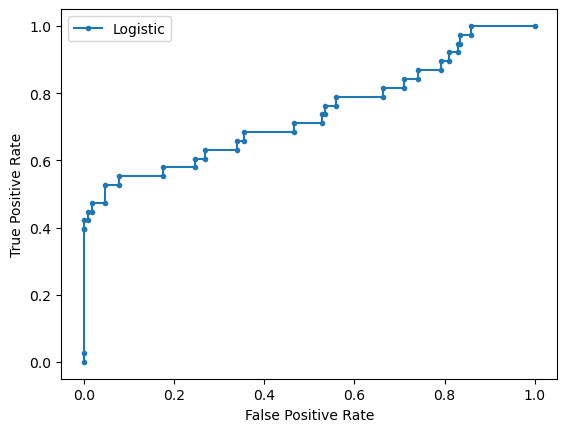

In [80]:
plt.plot(model_fpr,model_tpr,marker=".",label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

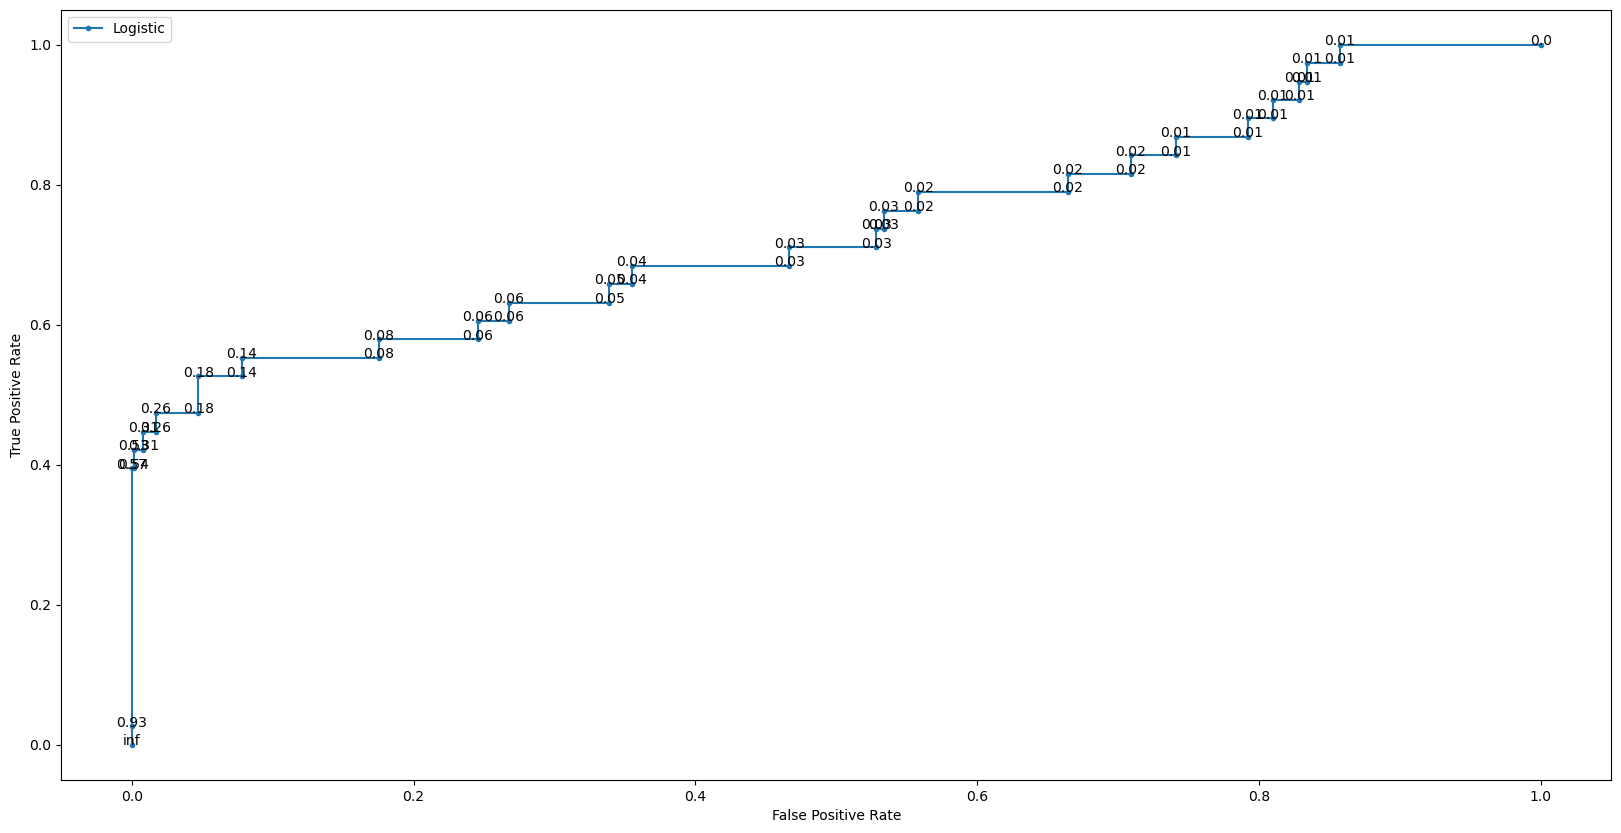

In [91]:
fig,ax = plt.subplots(figsize=(20,10))

ax.plot(model_fpr, model_tpr, marker=".", label="Logistic")

for fpr,tpr,thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{np.round(thresh,2)}",(fpr,tpr),ha="center")
    
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [86]:
custom_threshold = 0.2

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2370   20]
 [  92   18]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2390
           1       0.47      0.16      0.24       110

    accuracy                           0.96      2500
   macro avg       0.72      0.58      0.61      2500
weighted avg       0.94      0.96      0.94      2500



In [87]:
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0])

In [88]:
custom_threshold = 0.01

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[ 459    3]
 [2003   35]]
              precision    recall  f1-score   support

           0       0.19      0.99      0.31       462
           1       0.92      0.02      0.03      2038

    accuracy                           0.20      2500
   macro avg       0.55      0.51      0.17      2500
weighted avg       0.79      0.20      0.09      2500



In [89]:
custom_threshold = 0.5

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2459   22]
 [   3   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

